# VMGP-VAE per AdaptMap Dataset

Questo notebook implementa l'architettura VAE descritta nel paper VMGP[cite: 36, 88], adattata per i dati genomici caprini del progetto AdaptMap.
Il codice utilizza **PyTorch Lightning** per una gestione modulare del training e **pandas-plink** per la lettura efficiente dei file `.bed/.bim/.fam`.

## Requisiti
Assicurati di avere installato:
`pip install torch torchvision pytorch-lightning pandas-plink matplotlib seaborn scikit-learn`

In [6]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import pytorch_lightning as pl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from torch.utils.data import DataLoader, TensorDataset
from typing import Optional, Tuple
from sklearn.model_selection import KFold, train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from pandas_plink import read_plink
from pytorch_lightning.callbacks import EarlyStopping

In [ ]:
class AdaptMapDataModule(pl.LightningDataModule):
    """
    DataModule per dataset AdaptMap caricato da file PLINK (.bed, .bim, .fam).
    Implementa il preprocessing completo con QC e stratified k-fold CV.
    """
    
    def __init__(
        self,
        data_dir: str = "./data/",
        batch_size: int = 32,
        num_workers: int = 4,
        k_folds: int = 5,
        current_fold: int = 0,
        seed: int = 42,
        sample_missing_threshold: float = 0.10,
        snp_missing_threshold: float = 0.05,
        maf_threshold: float = 0.01,
        min_samples_per_breed: int = 2,
        val_split: float = 0.15,
        test_split: float = 0.15,
        ld_pruning: bool = False,
        ld_threshold: float = 0.2,
        **kwargs
    ):
        super().__init__()
        self.save_hyperparameters()
        
        self.data_dir = data_dir
        self.batch_size = batch_size
        self.num_workers = num_workers
        self.k_folds = k_folds
        self.current_fold = current_fold
        self.seed = seed
        
        # Parametri QC
        self.sample_missing_threshold = sample_missing_threshold
        self.snp_missing_threshold = snp_missing_threshold
        self.maf_threshold = maf_threshold
        self.min_samples_per_breed = min_samples_per_breed
        self.val_split = val_split
        self.test_split = test_split
        
        # Parametri LD Pruning
        self.ld_pruning = ld_pruning
        self.ld_threshold = ld_threshold
        
        # Dati processati
        self.X_processed = None
        self.y_labels = None
        self.num_snps = None
        self.num_breeds = None
        
        # Dataset splits
        self.train_dataset = None
        self.val_dataset = None
        self.test_dataset = None
        
    def prepare_data(self):
        if not os.path.exists(self.data_dir):
             print(f"⚠️ Warning: Directory {self.data_dir} non trovata.")
             return
        bed_files = [f for f in os.listdir(self.data_dir) if f.endswith('.bed')]
        if len(bed_files) == 0:
            raise FileNotFoundError(f"Nessun file .bed trovato in {self.data_dir}")
        print(f"✅ Trovati {len(bed_files)} file(s) .bed in {self.data_dir}")
    
    def setup(self, stage: Optional[str] = None):
        if self.X_processed is not None:
            return
        
        print(f"\n{'='*60}")
        print("SETUP DataModule - Caricamento e Preprocessing Dataset AdaptMap")
        print(f"{'='*60}\n")
        
        X_raw, y_raw = self._load_plink_data()
        X_processed, y_processed = self._apply_qc_and_preprocessing(X_raw, y_raw)
        X_filtered, y_filtered = self._filter_rare_breeds(X_processed, y_processed)
        y_encoded = self._encode_labels(y_filtered)
        
        self.X_processed = X_filtered
        self.y_labels = y_encoded
        self.num_snps = X_filtered.shape[1]
        
        print(f"\n✅ PREPROCESSING COMPLETATO")
        print(f"   Campioni finali: {self.X_processed.shape[0]}")
        print(f"   SNPs finali: {self.num_snps}")
        print(f"   Razze finali: {self.num_breeds}")
        
        self._create_splits(stage)
    
    def _load_plink_data(self) -> Tuple[np.ndarray, np.ndarray]:
        try:
            bed_files = [f for f in os.listdir(self.data_dir) if f.endswith('.bed')]
            if not bed_files: raise FileNotFoundError("File .bed mancante")
            file_prefix = os.path.splitext(bed_files[0])[0]
            dataset_file = os.path.join(self.data_dir, file_prefix)
            
            print(f"📂 Caricamento dataset PLINK: {dataset_file}")
            (bim, fam, G) = read_plink(dataset_file, verbose=False)
            
            if 'fid' in fam.columns and fam['fid'].nunique() > 1:
                y_raw = fam['fid'].to_numpy()
            else:
                y_raw = fam['iid'].to_numpy()
            
            print("   Conversione matrice genotipi...")
            X_raw = G.compute().T
            return X_raw, y_raw
        except Exception as e:
            raise RuntimeError(f"Errore nel caricamento PLINK: {e}")
    
    def _apply_qc_and_preprocessing(self, X_raw, y_raw):
        print(f"\n1️⃣  QC Campioni (threshold: {self.sample_missing_threshold*100}%)")
        missing_per_sample = np.isnan(X_raw).mean(axis=1)
        keep_samples_idx = missing_per_sample < self.sample_missing_threshold
        X_qc = X_raw[keep_samples_idx]
        y_qc = y_raw[keep_samples_idx]
        
        print(f"\n2️⃣  QC SNP - Missingness (threshold: {self.snp_missing_threshold*100}%)")
        missing_per_snp = np.isnan(X_qc).mean(axis=0)
        keep_snps_idx = missing_per_snp < self.snp_missing_threshold
        X_qc = X_qc[:, keep_snps_idx]
        
        print(f"\n3️⃣  QC SNP - MAF (threshold: {self.maf_threshold*100}%)")
        mean_allele_freq = np.nanmean(X_qc, axis=0) / 2.0
        maf = np.minimum(mean_allele_freq, 1.0 - mean_allele_freq)
        keep_snps_maf_idx = maf >= self.maf_threshold
        X_qc = X_qc[:, keep_snps_maf_idx]
        
        print(f"\n4️⃣  Imputazione valori mancanti")
        imputer = SimpleImputer(strategy='most_frequent')
        X_imputed = imputer.fit_transform(X_qc)
        
        # 🚀 LD PRUNING
        if self.ld_pruning:
            X_imputed = self._prune_ld(X_imputed, threshold=self.ld_threshold)
        
        print("5️⃣  Normalizzazione genotipi (0,1,2) -> (0.0, 0.5, 1.0)")
        # Normalizzazione corretta per il range [0, 1]
        # 0 -> 0.0, 1 -> 0.5, 2 -> 1.0
        X_scaled = X_imputed / 2.0
        
        return X_scaled, y_qc
    
    def _prune_ld(self, X, window_size=50, step_size=5, threshold=0.2):
        """
        LD Pruning usando algoritmo greedy simile a PLINK --indep-pairwise
        
        Args:
            window_size: Numero di SNP nella finestra
            step_size: Spostamento della finestra (default 5)
            threshold: Soglia r² (default 0.2)
        """
        print(f"\n✂️  LD Pruning (Window={window_size}, Step={step_size}, R²={threshold})...")
        n_samples, n_snps = X.shape
        
        # Standardize
        print("   Calcolo statistiche per correlazione...")
        X_mean = np.mean(X, axis=0)
        X_std = np.std(X, axis=0)
        X_std[X_std == 0] = 1
        X_norm = (X - X_mean) / X_std
        
        to_remove = np.zeros(n_snps, dtype=bool)
        
        try:
            device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
            print(f"   Using device: {device}")
            X_tensor = torch.tensor(X_norm, device=device, dtype=torch.float32)
            
            print(f"   Analizzando {n_snps} SNPs...")
            
            # ALGORITMO GREEDY CORRETTO
            i = 0
            while i < n_snps:
                if to_remove[i]:
                    i += 1
                    continue
                
                # Finestra: da i+1 a i+window_size
                start = i + 1
                end = min(i + 1 + window_size, n_snps)
                
                if start >= end:
                    i += step_size
                    continue
                
                # Filtra SNP già rimossi nella finestra
                window_indices = []
                for j in range(start, end):
                    if not to_remove[j]:
                        window_indices.append(j)
                
                if len(window_indices) == 0:
                    i += step_size
                    continue
                
                # Calcola correlazioni
                pivot = X_tensor[:, i].unsqueeze(1)  # (N, 1)
                targets = X_tensor[:, window_indices]  # (N, W)
                
                corrs = torch.mm(pivot.t(), targets).squeeze(0) / n_samples
                r2 = corrs ** 2
                
                # Rimuovi SNP con r² > threshold (SOLO nella finestra corrente)
                bad_mask = r2 > threshold
                if torch.any(bad_mask):
                    bad_local = torch.nonzero(bad_mask).squeeze(-1).cpu().numpy()
                    # Converti indici locali in globali
                    bad_global = [window_indices[idx] for idx in bad_local]
                    to_remove[bad_global] = True
                
                # Scorri con step_size
                i += step_size
                
                if i % 1000 == 0 and i > 0:
                    removed_so_far = np.sum(to_remove)
                    print(f"   ... processed {i}/{n_snps} SNPs, removed {removed_so_far}")
                    
        except Exception as e:
            print(f"⚠️  Errore LD Pruning: {e}. Skipping.")
            import traceback
            traceback.print_exc()
            return X
        
        kept_indices = np.where(~to_remove)[0]
        removed = np.sum(to_remove)
        print(f"   ✅ Rimossi {removed} SNPs ({removed/n_snps*100:.1f}%). Rimasti: {len(kept_indices)}")
        
        return X[:, kept_indices]

    
    def _filter_rare_breeds(self, X, y):
        unique, counts = np.unique(y, return_counts=True)
        breed_counts = dict(zip(unique, counts))
        min_required = max(self.min_samples_per_breed, 7)
        valid_breeds = [b for b, c in breed_counts.items() if c >= min_required]
        valid_mask = np.isin(y, valid_breeds)
        return X[valid_mask], y[valid_mask]
    
    def _encode_labels(self, y):
        self.label_encoder = LabelEncoder()
        y_encoded = self.label_encoder.fit_transform(y)
        self.num_breeds = len(self.label_encoder.classes_)
        return y_encoded
    
    def _create_splits(self, stage):
        X_tensor = torch.FloatTensor(self.X_processed)
        y_tensor = torch.LongTensor(self.y_labels)
        kf = KFold(n_splits=self.k_folds, shuffle=True, random_state=self.seed)
        all_indices = np.arange(len(X_tensor))
        folds = list(kf.split(all_indices))
        train_val_idx, test_idx = folds[self.current_fold]
        train_idx, val_idx = train_test_split(
            train_val_idx, test_size=self.val_split / (1 - self.test_split),
            random_state=self.seed, stratify=self.y_labels[train_val_idx]
        )
        if stage == 'fit' or stage is None:
            self.train_dataset = TensorDataset(X_tensor[train_idx], y_tensor[train_idx])
            self.val_dataset = TensorDataset(X_tensor[val_idx], y_tensor[val_idx])
        if stage == 'test' or stage is None:
            self.test_dataset = TensorDataset(X_tensor[test_idx], y_tensor[test_idx])

    def train_dataloader(self):
        return DataLoader(self.train_dataset, batch_size=self.batch_size, shuffle=True, num_workers=self.num_workers)
    def val_dataloader(self):
        return DataLoader(self.val_dataset, batch_size=self.batch_size, shuffle=False, num_workers=self.num_workers)
    def test_dataloader(self):
        return DataLoader(self.test_dataset, batch_size=self.batch_size, shuffle=False, num_workers=self.num_workers)

In [8]:
class VMGP_VAE(pl.LightningModule):
    def __init__(self, input_dim: int, latent_dim: int = 32, lr: float = 1e-3, 
                 beta_start: float = 0.001, beta_end: float = 0.05, beta_warmup_epochs: int = 30,
                 class_weights: Optional[torch.Tensor] = None):
        super().__init__()
        self.save_hyperparameters(ignore=['class_weights'])
        
        # Register weights as buffer (auto-move to device)
        if class_weights is not None:
            self.register_buffer('class_weights', class_weights)
        else:
            self.class_weights = None

        # Dimensioni specificate nel paper VMGP
        self.d1 = 2048
        self.d2 = 512
        
        # --- ENCODER ---
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, self.d1),
            nn.BatchNorm1d(self.d1),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.1),
            nn.Linear(self.d1, self.d2),
            nn.BatchNorm1d(self.d2),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.1)
        )
        
        # --- SAMPLER (Latent Space) ---
        self.fc_mu = nn.Linear(self.d2, latent_dim)
        self.fc_var = nn.Linear(self.d2, latent_dim)
        
        # --- DECODER ---
        self.decoder_input = nn.Linear(latent_dim, self.d2)
        self.decoder = nn.Sequential(
            nn.BatchNorm1d(self.d2),
            nn.LeakyReLU(0.2),
            nn.Linear(self.d2, self.d1),
            nn.BatchNorm1d(self.d1),
            nn.LeakyReLU(0.2),
            # Output 1 valore per SNP (Regressione)
            nn.Linear(self.d1, input_dim),
            nn.Sigmoid()
        )
        
        # 🚀 INIT BIAS TRICK
        # Inizializza il bias dell'ultimo layer lineare a -2.0
        # Sigmoid(-2.0) ~= 0.12, che è molto più vicino a 0.0 (HomRef) rispetto a 0.5
        # Questo aiuta il modello a partire predicendo la classe maggioritaria
        self.decoder[5].bias.data.fill_(-2.0)
        
        # 🚀 BETA SCHEDULER
        self.beta_start = beta_start
        self.beta_end = beta_end
        self.beta_warmup_epochs = beta_warmup_epochs
        self.current_beta = beta_start

    def on_train_epoch_start(self):
        """🚀 AGGIORNA BETA AD OGNI EPOCA (linear warmup)"""
        if self.current_epoch < self.beta_warmup_epochs:
            progress = self.current_epoch / self.beta_warmup_epochs
            self.current_beta = self.beta_start + (self.beta_end - self.beta_start) * progress
        else:
            self.current_beta = self.beta_end
        
        self.log('beta', self.current_beta, prog_bar=False)

    def reparameterize(self, mu, logvar):
        if self.training:
            std = torch.exp(0.5 * logvar)
            eps = torch.randn_like(std)
            return mu + eps * std
        else:
            return mu

    def forward(self, x):
        encoded = self.encoder(x)
        mu = self.fc_mu(encoded)
        logvar = self.fc_var(encoded)
        z = self.reparameterize(mu, logvar)
        
        decoded_input = self.decoder_input(z)
        reconstruction = self.decoder(decoded_input)
        
        return reconstruction, mu, logvar

    def loss_function(self, recon_x, x, mu, logvar):
        # MSE element-wise
        mse = (recon_x - x) ** 2
        
        # Applicazione CORRETTA dei pesi per classe
        if self.class_weights is not None:
            # Crea tensor dei 
            # con stessa shape di x
            weights = torch.zeros_like(x)
            
            # Mappa ogni genotipo al suo peso
            # HomRef (0.0) -> weight[0]
            # Het (0.5) -> weight[1]  
            # HomAlt (1.0) -> weight[2]
            mask_homref = (x == 0.0)
            mask_het = (x == 0.5)
            mask_homalt = (x == 1.0)
            
            weights[mask_homref] = self.class_weights[0]
            weights[mask_het] = self.class_weights[1]
            weights[mask_homalt] = self.class_weights[2]
            
            # MSE pesato
            mse = mse * weights
        
        recon_loss = mse.mean()
        kld_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
        
        return recon_loss + self.current_beta * kld_loss, recon_loss, kld_loss


    def training_step(self, batch, batch_idx):
        x, y = batch 
        recon_x, mu, logvar = self(x)
        loss, recon_loss, kld = self.loss_function(recon_x, x, mu, logvar)
        
        self.log('train_loss', loss, prog_bar=True)
        self.log('train_recon', recon_loss, prog_bar=True)
        self.log('train_kld', kld, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        recon_x, mu, logvar = self(x)
        loss, recon_loss, kld = self.loss_function(recon_x, x, mu, logvar)
        
        self.log('val_loss', loss, prog_bar=True)
        self.log('val_recon', recon_loss)
        self.log('val_kld', kld)
        return loss

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.hparams.lr)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, 
            mode='min', 
            factor=0.5, 
            patience=5, 
        )
        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "monitor": "val_loss",
                "interval": "epoch",
                "frequency": 1
            },
        }

In [ ]:
# === CONFIGURAZIONE ===
# Sostituisci con la tua cartella
DATA_DIR = "./data/" 
BATCH_SIZE = 128 

# Ottimizzazione per Tensor Cores
torch.set_float32_matmul_precision('medium')

# 1. Setup Dati
dm = AdaptMapDataModule(
    data_dir=DATA_DIR,
    batch_size=BATCH_SIZE,
    sample_missing_threshold=0.10, 
    snp_missing_threshold=0.05,    
    maf_threshold=0.01,            
    k_folds=5,
    current_fold=0,
    num_workers=4,
    # 🚀 LD PRUNING ATTIVATO
    ld_pruning=True,
    ld_threshold=0.2
)

# Eseguiamo setup per calcolare numero SNPs e Pesi
try:
    dm.prepare_data()
    dm.setup()
    print(f"Input Dimension (SNPs): {dm.num_snps}")
    
    # --- CALCOLO PESI PER BILANCIAMENTO CLASSI ---
    print("Calcolo pesi delle classi...")
    # Campioniamo un subset per velocità se il dataset è enorme, o usiamo tutto se sta in RAM
    # Qui usiamo X_processed che è numpy array
    flat_data = dm.X_processed.flatten()
    # Valori attesi: 0.0, 0.5, 1.0
    # Arrotondiamo per sicurezza
    flat_rounded = np.round(flat_data * 2).astype(int) # 0, 1, 2
    counts = np.bincount(flat_rounded, minlength=3)
    total = len(flat_rounded)
    
    print(f"Conteggi: HomRef(0)={counts[0]}, Het(1)={counts[1]}, HomAlt(2)={counts[2]}")
    
    # Inverse Frequency Weighting: N / (3 * count)
    # Aggiungiamo epsilon per evitare divisioni per zero
    weights_np = total / (3 * counts + 1e-6)
    
    # Normalizziamo i pesi in modo che la media sia 1 (opzionale, ma aiuta a mantenere la scala della loss)
    weights_np = weights_np / weights_np.mean()
    
    class_weights = torch.tensor(weights_np, dtype=torch.float32)
    print(f"Pesi calcolati: {class_weights}")
    
    # 2. Setup Modello con Pesi e Init Bias
    model = VMGP_VAE (
        input_dim=dm.num_snps, 
        latent_dim=128,
        lr=0.001,
        class_weights=class_weights, # Passiamo i pesi al modello
        # Nel modello VMGPVAE, modifica:
        beta_start = 0.0001,  # Più basso
        beta_end = 0.01,      # Più basso  
        beta_warmup_epochs = 80  # Più lungo
    )

    # 3. Trainer Ottimizzato
    trainer = pl.Trainer(
        max_epochs=100,
        accelerator="auto",
        devices=1 if torch.cuda.is_available() else "auto",
        precision="16-mixed" if torch.cuda.is_available() else 32, 
        callbacks=[EarlyStopping(monitor="val_loss", patience=20, mode="min")],
        log_every_n_steps=10
    )

    # 4. Avvio
    print("Avvio training...")
    trainer.fit(model, dm)

except Exception as e:
    print(f"Errore durante il setup: {e}")
    import traceback
    traceback.print_exc()

✅ Trovati 1 file(s) .bed in ./data/

SETUP DataModule - Caricamento e Preprocessing Dataset AdaptMap

📂 Caricamento dataset PLINK: ./data/ADAPTmap_genotypeTOP_20160222_full
   Conversione matrice genotipi...

1️⃣  QC Campioni (threshold: 10.0%)

2️⃣  QC SNP - Missingness (threshold: 5.0%)

3️⃣  QC SNP - MAF (threshold: 1.0%)

4️⃣  Imputazione valori mancanti


KeyboardInterrupt: 

: 


📊 METRICHE GLOBALI:
   MSE (Mean Squared Error):      0.10262
   MAE (Mean Absolute Error):     0.25839
   R² Score:                      0.25883
   Pearson Correlation:           0.56671

🧬 CONCORDANZA GENOTIPICA:
   Accuracy Globale:              55.99%

🔍 ANALISI PER GENOTIPO:
   HomRef (0/0)   :  43.36% (su 1100703 SNP)
   Het (0/1)      :  70.06% (su 2295032 SNP)
   HomAlt (1/1)   :  49.64% (su 2897001 SNP)


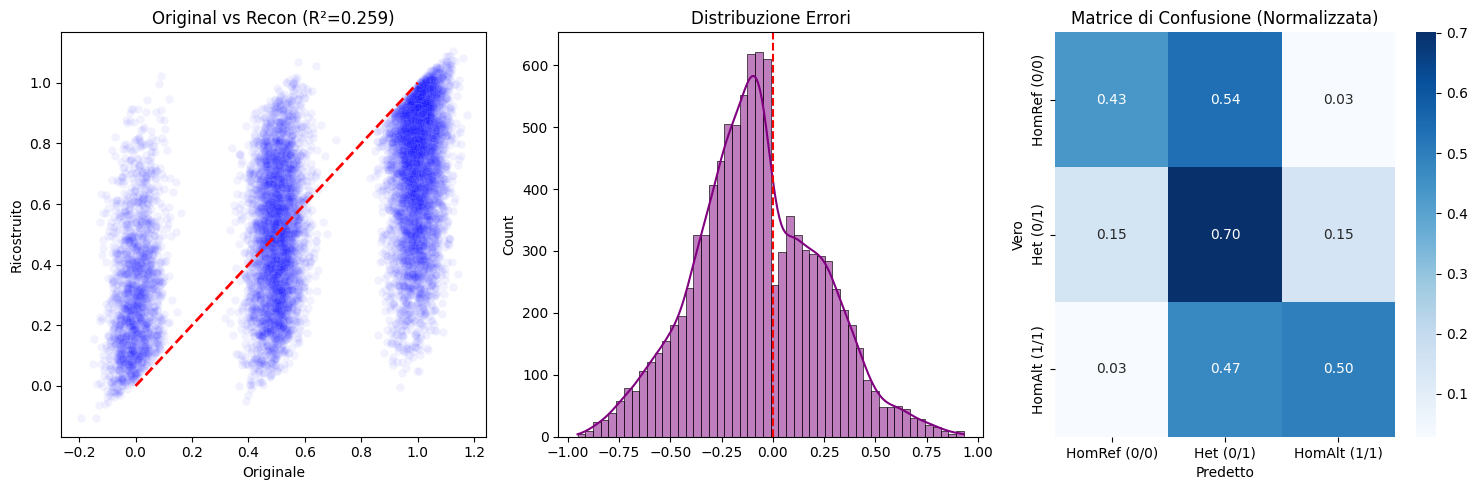

In [ ]:
# ============================================================================
# VALUTAZIONE DETTAGLIATA
# ============================================================================
from sklearn.metrics import r2_score, mean_absolute_error
from scipy.stats import pearsonr

model.eval()
model.freeze()

# Preleva batch di validazione
val_loader = dm.val_dataloader()
batch = next(iter(val_loader))
x_val, y_val = batch

# Forward pass
with torch.no_grad():
    recon_x, mu, logvar = model(x_val)
    # recon_x è già output di Sigmoid (0-1)

# Converti in numpy
orig_np = x_val.cpu().numpy()
recon_np = recon_x.cpu().numpy()

# Flatten per metriche globali
orig_flat = orig_np.flatten()
recon_flat = recon_np.flatten()

# --- 1. METRICHE GLOBALI ---
mse = np.mean((orig_flat - recon_flat)**2)
mae = mean_absolute_error(orig_flat, recon_flat)
r2 = r2_score(orig_flat, recon_flat)
corr, _ = pearsonr(orig_flat, recon_flat)

print(f"\n📊 METRICHE GLOBALI:")
print(f"   MSE (Mean Squared Error):      {mse:.5f}")
print(f"   MAE (Mean Absolute Error):     {mae:.5f}")
print(f"   R² Score:                      {r2:.5f}")
print(f"   Pearson Correlation:           {corr:.5f}")

# --- 2. CONCORDANZA GENOTIPICA ---
# Arrotonda ai valori discreti più vicini {0.0, 0.5, 1.0}
def round_genotypes(x):
    return np.round(x * 2) / 2.0

recon_rounded = round_genotypes(recon_np)
concordance = (orig_np == recon_rounded).mean()

print(f"\n🧬 CONCORDANZA GENOTIPICA:")
print(f"   Accuracy Globale:              {concordance*100:.2f}%")

# --- 3. ANALISI PER CLASSE (0, 0.5, 1) ---
print(f"\n🔍 ANALISI PER GENOTIPO:")
classes = [0.0, 0.5, 1.0]
labels = ["HomRef (0/0)", "Het (0/1)", "HomAlt (1/1)"]

for cls, label in zip(classes, labels):
    mask = (orig_np == cls)
    if mask.sum() > 0:
        acc = (recon_rounded[mask] == cls).mean()
        count = mask.sum()
        print(f"   {label:15s}: {acc*100:6.2f}% (su {count} SNP)")

# --- 4. PLOTTING ---
# Campionamento per scatter plot leggero
idx = np.random.choice(len(orig_flat), 10000, replace=False)
orig_sample = orig_flat[idx]
recon_sample = recon_flat[idx]

plt.figure(figsize=(15, 5))

# Scatter Plot
plt.subplot(1, 3, 1)
# Jitter per visualizzare meglio i punti discreti
jitter = np.random.normal(0, 0.05, size=len(orig_sample))
sns.scatterplot(x=orig_sample + jitter, y=recon_sample + jitter, alpha=0.05, color="blue")
plt.plot([0, 1], [0, 1], 'r--', lw=2)
plt.title(f"Original vs Recon (R²={r2:.3f})")
plt.xlabel("Originale")
plt.ylabel("Ricostruito")

# Istogramma Errori
plt.subplot(1, 3, 2)
errors = recon_sample - orig_sample
sns.histplot(errors, bins=50, kde=True, color="purple")
plt.title("Distribuzione Errori")
plt.axvline(0, color='red', linestyle='--')

# Confusion Matrix (Heatmap)
plt.subplot(1, 3, 3)
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(
    (orig_flat * 2).astype(int), 
    (recon_rounded.flatten() * 2).astype(int), 
    labels=[0, 1, 2],
    normalize='true'
)
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", 
            xticklabels=labels, yticklabels=labels)
plt.title("Matrice di Confusione (Normalizzata)")
plt.ylabel("Vero")
plt.xlabel("Predetto")

plt.tight_layout()
plt.show()